<a href="https://colab.research.google.com/github/jessicasalazar/vision_computador/blob/main/cv_taller5_V2_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

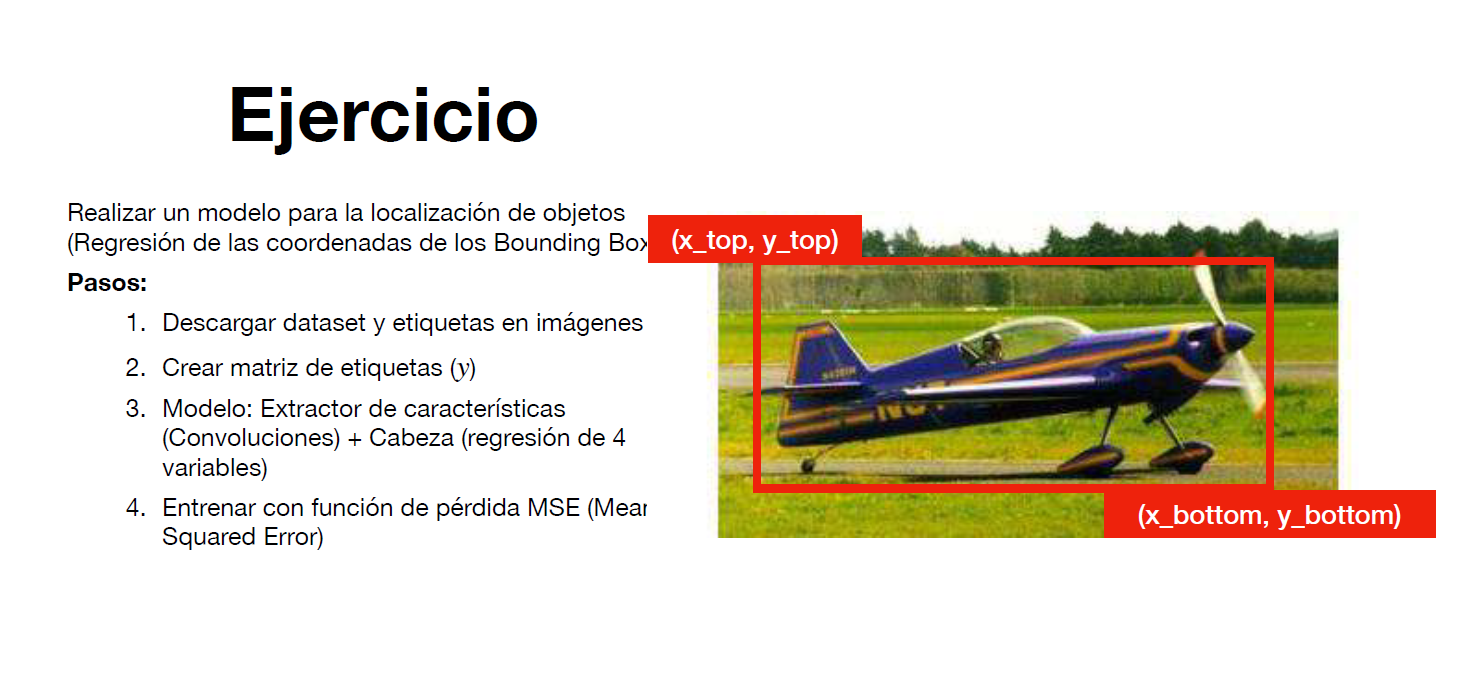

In [1]:
!unzip "/content/Data.zip"

Archive:  /content/Data.zip
   creating: Data/
  inflating: Data/Airplanes.csv      
  inflating: __MACOSX/Data/._Airplanes.csv  
  inflating: Data/airplanes.zip      
  inflating: Data/pre-processing.py  
  inflating: __MACOSX/Data/._pre-processing.py  


In [2]:
!ls

Data  Data.zip	__MACOSX  sample_data


In [3]:
!unzip -q /content/Data/airplanes.zip -d /content/Data

In [4]:
import pandas as pd
from PIL import Image
import glob
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import cv2 as cv

import tensorflow as tf
from tensorflow.data import Dataset
from keras.applications import ResNet50
from keras import layers, models, losses, optimizers, utils, preprocessing
import tensorflow_datasets as tfds




#Explaration Data Analysis


In [5]:
images_directory = '/content/Data/airplanes'
list_dir = os.listdir(images_directory)
list_dir.sort()
list_dir
#dic_label = {i:list_dir[i]  for i in range(len(list_dir))}
dic_label = {index:name for index, name in enumerate(list_dir)}
#dic_label
#list_dir

In [140]:
df = pd.read_csv('/content/Data/Airplanes.csv')
top_left_corner, bottom_right_corner, color, thickness = df.loc[df['Image'] =='image_0002.jpg'][['y_top',	'y_bottom',	'x_top',	'x_bottom']].iloc[0]

In [141]:
type(top_left_corner), bottom_right_corner, color, thickness

(int, 153, 59, 342)

The coordinates are adjusted for an image size of 300 × 300 in order to train the model.

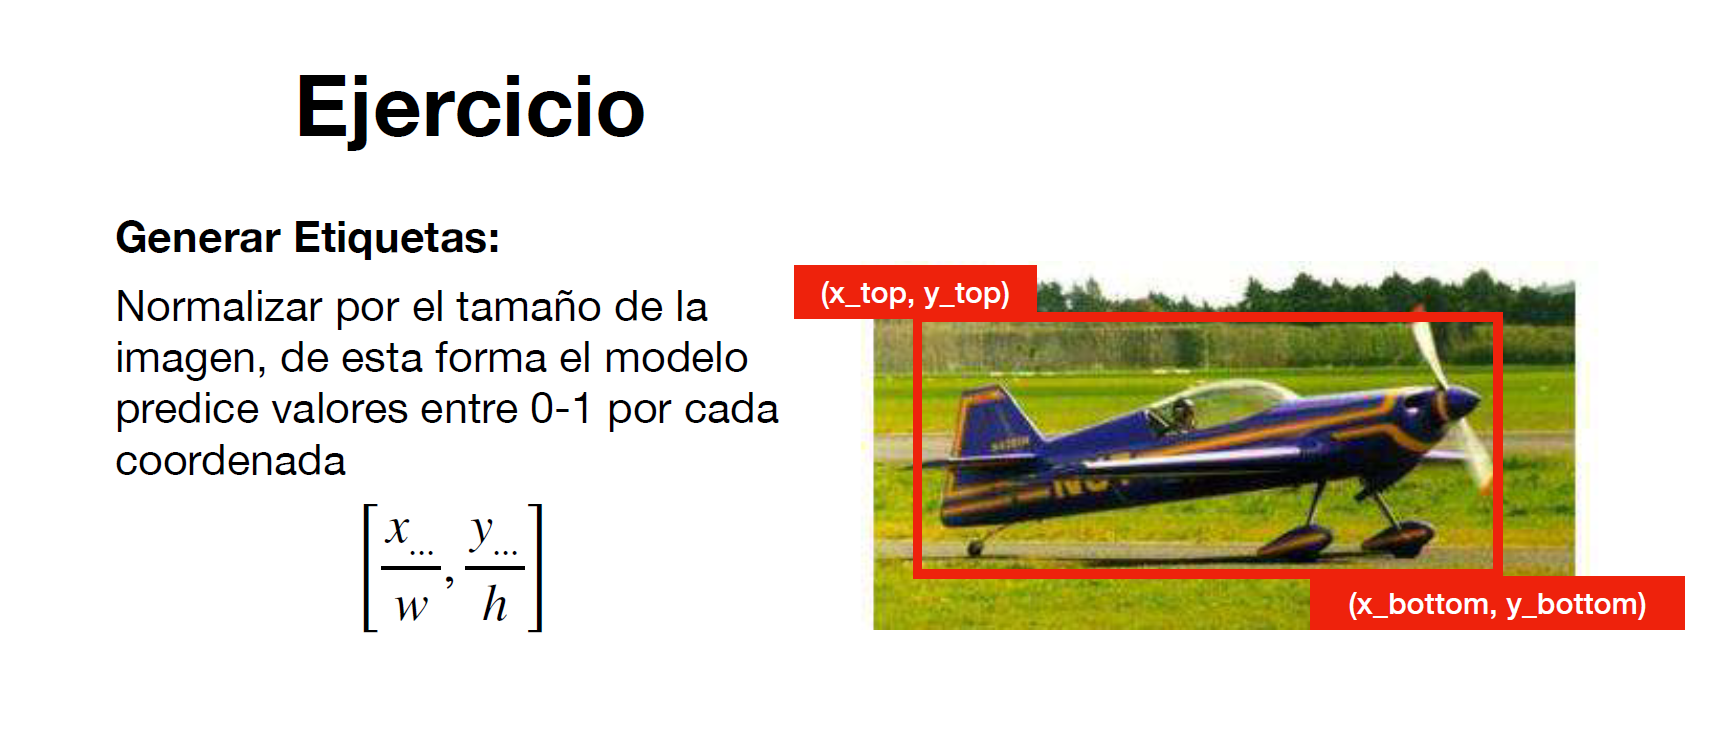

In [142]:
#list_dir
df
size = (300,300)

for index, row in df.iterrows():
  img = cv.imread(images_directory+'/'+row['Image'])
  y_top,	y_bottom,	x_top,	x_bottom = df.loc[df['Image'] == row['Image']][['y_top',	'y_bottom',	'x_top',	'x_bottom']].iloc[0]
  h, w, _ = img.shape

  y_top = row['y_top']
  y_bottom = row['y_bottom']
  x_top = row['x_top']
  x_bottom = row['x_bottom']
  x_top_n = int(x_top * size[0] / w)
  y_top_n = int(y_top * size[1] / h)
  x_bottom_n = int(x_bottom * size[0] / w)
  y_bottom_n = int(y_bottom * size[1] / h)

  df.at[index, 'x_top_n'] = x_top_n
  df.at[index, 'y_top_n'] = y_top_n
  df.at[index, 'x_bottom_n'] = x_bottom_n
  df.at[index, 'y_bottom_n'] = y_bottom_n

df

,Unnamed: 0,Image,y_top,y_bottom,x_top,x_bottom,label,x_top_n,y_top_n,x_bottom_n,y_bottom_n
0,0,image_0001.jpg,30,137,49,349,Airplanes,36.0,54.0,263.0,250.0
1,0,image_0002.jpg,35,153,59,342,Airplanes,44.0,57.0,255.0,249.0
2,0,image_0003.jpg,36,135,47,331,Airplanes,35.0,65.0,252.0,245.0
3,0,image_0004.jpg,24,141,47,342,Airplanes,35.0,42.0,261.0,248.0
4,0,image_0005.jpg,18,146,48,339,Airplanes,36.0,30.0,257.0,248.0
...,...,...,...,...,...,...,...,...,...,...,...
795,0,image_0796.jpg,27,118,57,356,Airplanes,41.0,56.0,259.0,245.0
796,0,image_0797.jpg,25,110,56,350,Airplanes,41.0,55.0,259.0,242.0
797,0,image_0798.jpg,25,110,59,354,Airplanes,43.0,56.0,259.0,248.0
798,0,image_0799.jpg,26,116,49,347,Airplanes,36.0,55.0,261.0,246.0


In [143]:
def bbox_img_resize(img ,y_top,	y_bottom,	x_top, x_bottom, size):
  h, w, _ = img.shape
  top_left_corner = (int(x_top*size[0]/w), int(y_top*size[1]/h))
  bottom_right_corner = (int(x_bottom*size[0]/w), int(y_bottom*size[1]/h)) # (x, y)
  im = cv.resize(img, size)
  return im, top_left_corner, bottom_right_corner

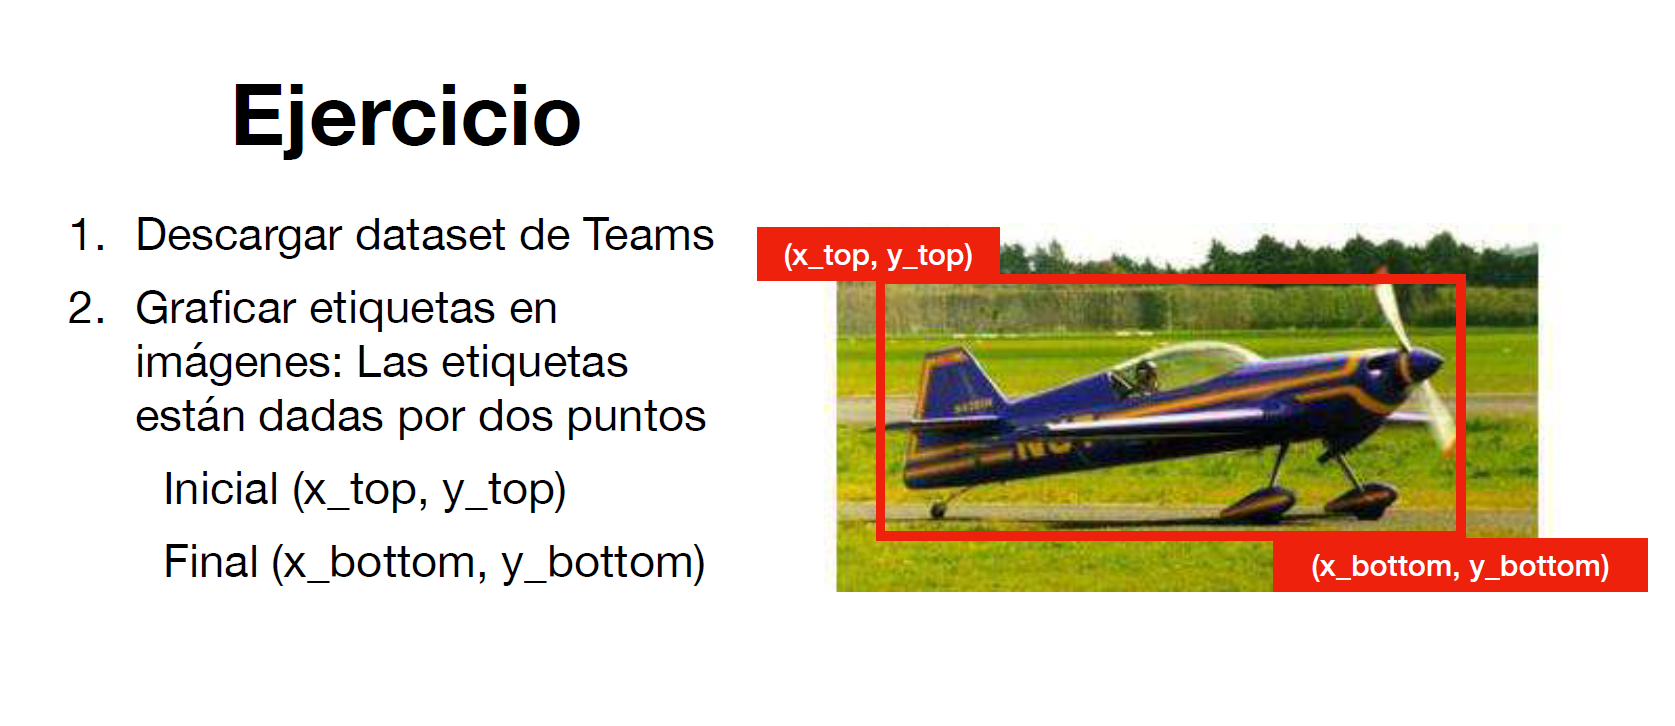

(300, 300, 3)
(300, 300, 3)
(300, 300, 3)
(300, 300, 3)
(300, 300, 3)
(300, 300, 3)
(300, 300, 3)
(300, 300, 3)
(300, 300, 3)


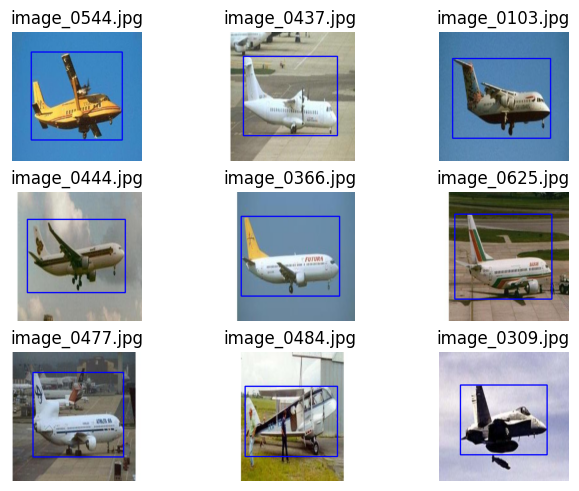

In [144]:
random_list = random.sample(list_dir,9)
fig, axs = plt.subplots(3,3, layout='constrained')

color = (0, 0, 255)
size = (300,300)
thickness = 2

for ax, class_dir  in zip(axs.flat, random_list):
  img = glob.glob(images_directory+'/*.jpg')
  img = random.choice(img)



  ax.set_title(class_dir)
  ax.set_axis_off()
  #print(img[24:])


  #print(df.loc[df['Image'] ==img[24:]][['y_top',	'y_bottom',	'x_top',	'x_bottom']])
  #im = Image.open(img)
  y_top,	y_bottom,	x_top,	x_bottom = df.loc[df['Image'] == img[24:]][['y_top',	'y_bottom',	'x_top',	'x_bottom']].iloc[0]
  top_left_corner = (x_top, y_top)  # (x, y)
  bottom_right_corner = (x_bottom, y_bottom) # (x, y)


  img = cv.imread(img)
  h, w, _ = img.shape

  img, top_left_corner, bottom_right_corner = bbox_img_resize(img ,y_top,	y_bottom,	x_top, x_bottom, size)

  print(img.shape)
  img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
  cv.rectangle(img, top_left_corner, bottom_right_corner, color, thickness)
  ax.imshow(img)

plt.show()

# Proposed architecture
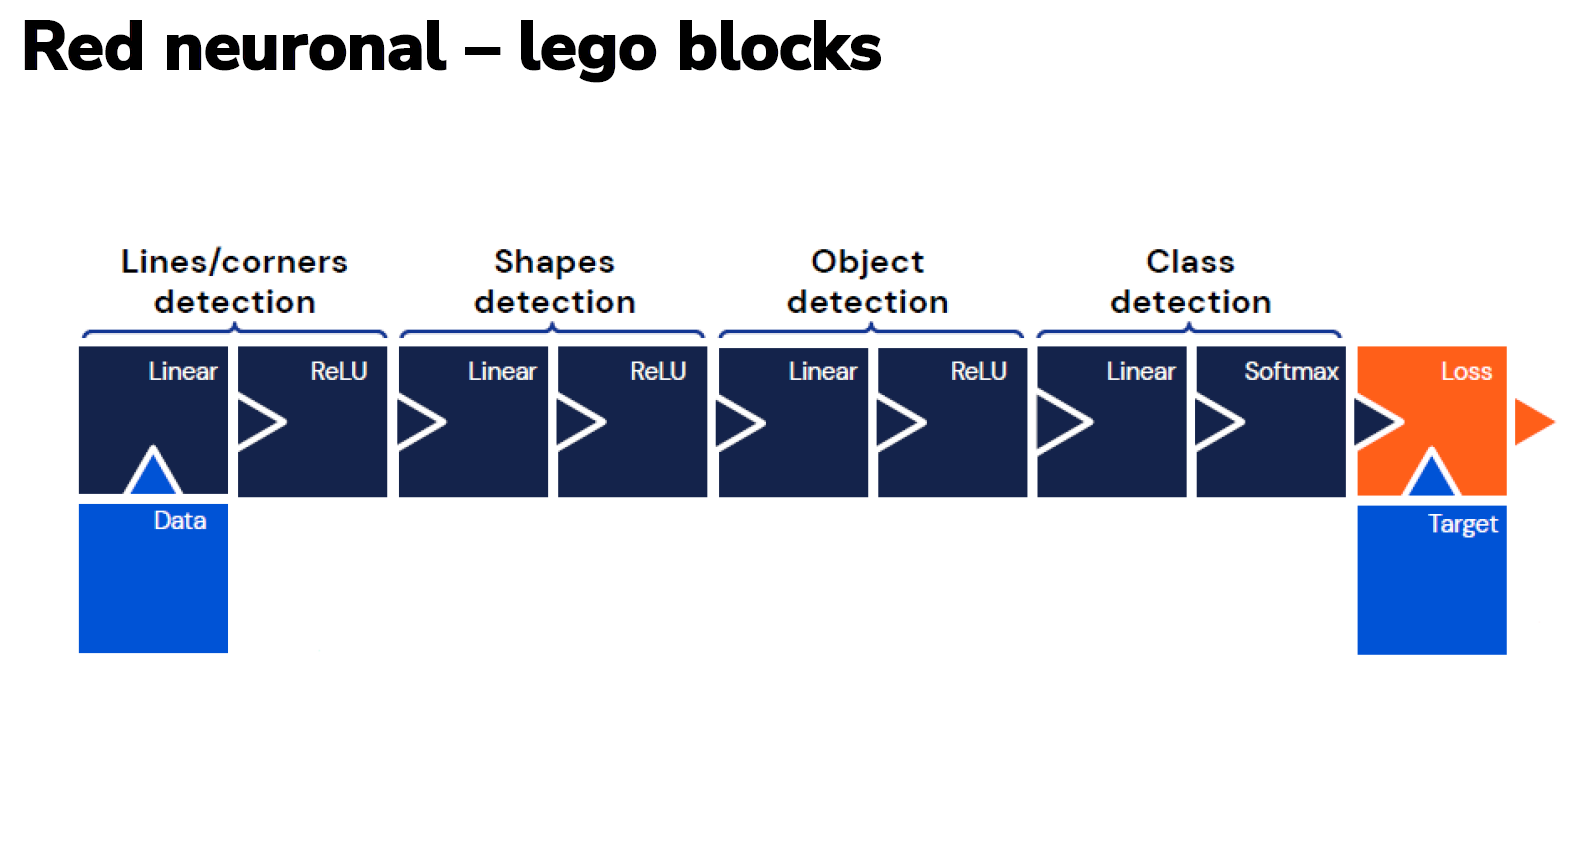
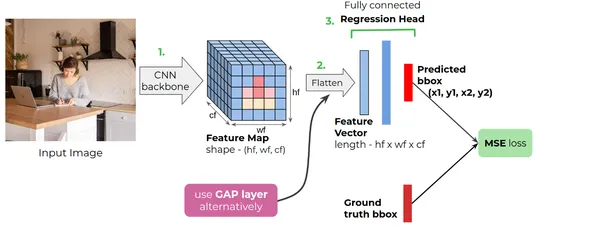

In [145]:
IMG_SHAPE = (300,300)

backbone = models.Sequential([
    ResNet50(include_top = False,
             weights = 'imagenet',
             input_shape = IMG_SHAPE + (3,)),
    layers.Conv2D(1024, 3, padding='same', activation='relu')
], name = "backbone")

spatial_vector = layers.GlobalAveragePooling2D(name = "GAP_vectorizer")

regression_head = models.Sequential([
    layers.Dense(512, activation='sigmoid'),
    layers.Dense(4,activation='sigmoid')
], name = "regression_head")


In [146]:
backbone.summary()

Model: "backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 10, 10, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 1024)   │    18,875,392 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,463,104 (161.98 MB)

 Trainable params: 42,409,984 (161.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [147]:
regression_head.summary()

Model: "regression_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## We applied a Sequential model to  stack of layers into the model.

In [148]:
bb_regressor = models.Sequential([
    backbone,
    spatial_vector,
    regression_head
])

In [149]:
bb_regressor.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ backbone (Sequential)           │ (None, 10, 10, 1024)   │    42,463,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP_vectorizer                  │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ regression_head (Sequential)    │ (None, 4)              │       526,852 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,989,956 (163.99 MB)

 Trainable params: 42,936,836 (163.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

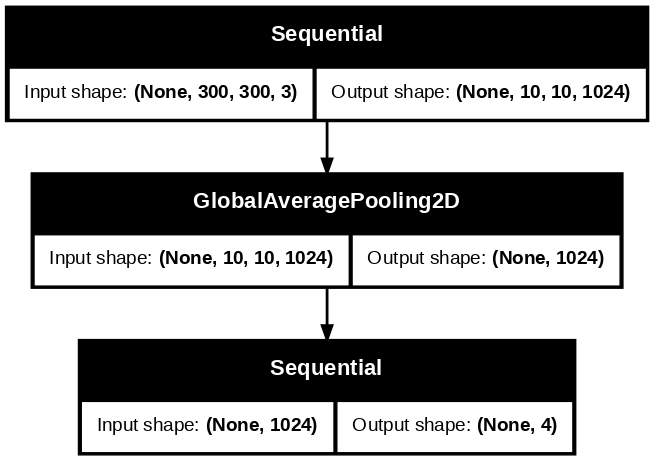

In [150]:
utils.plot_model(bb_regressor, "localizer.png", show_shapes=True, dpi = 100)

In [151]:
dir(tfds)

['GenerateMode',
 'ImageFolder',
 'ReadConfig',
 'Split',
 'TranslateFolder',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'annotations',
 'as_dataframe',
 'as_numpy',
 'audio',
 'beam',
 'benchmark',
 'builder',
 'builder_cls',
 'builder_from_directories',
 'builder_from_directory',
 'core',
 'd4rl',
 'data_source',
 'dataset_builders',
 'dataset_collection',
 'datasets',
 'decode',
 'deprecated',
 'disable_progress_bar',
 'display_progress_bar',
 'download',
 'enable_progress_bar',
 'even_splits',
 'features',
 'folder_dataset',
 'graphs',
 'image',
 'image_classification',
 'is_dataset_on_gcs',
 'list_builders',
 'list_dataset_collections',
 'load',
 'logging',
 'nearest_neighbors',
 'object_detection',
 'proto',
 'public_api',
 'question_answering',
 'ranking',
 'recommendation',
 'rl_unplugged',
 'rlds',
 'robomimic',
 'robotics',
 'show_examples',
 'show_statistics',
 's

In [152]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 32

## Preparation of coordenate values of the dataset

In [153]:
df_train = df.copy()
df_train

,Unnamed: 0,Image,y_top,y_bottom,x_top,x_bottom,label,x_top_n,y_top_n,x_bottom_n,y_bottom_n
0,0,image_0001.jpg,30,137,49,349,Airplanes,36.0,54.0,263.0,250.0
1,0,image_0002.jpg,35,153,59,342,Airplanes,44.0,57.0,255.0,249.0
2,0,image_0003.jpg,36,135,47,331,Airplanes,35.0,65.0,252.0,245.0
3,0,image_0004.jpg,24,141,47,342,Airplanes,35.0,42.0,261.0,248.0
4,0,image_0005.jpg,18,146,48,339,Airplanes,36.0,30.0,257.0,248.0
...,...,...,...,...,...,...,...,...,...,...,...
795,0,image_0796.jpg,27,118,57,356,Airplanes,41.0,56.0,259.0,245.0
796,0,image_0797.jpg,25,110,56,350,Airplanes,41.0,55.0,259.0,242.0
797,0,image_0798.jpg,25,110,59,354,Airplanes,43.0,56.0,259.0,248.0
798,0,image_0799.jpg,26,116,49,347,Airplanes,36.0,55.0,261.0,246.0


## The new coordinates are normalized according to the size of the image that the model will receive.

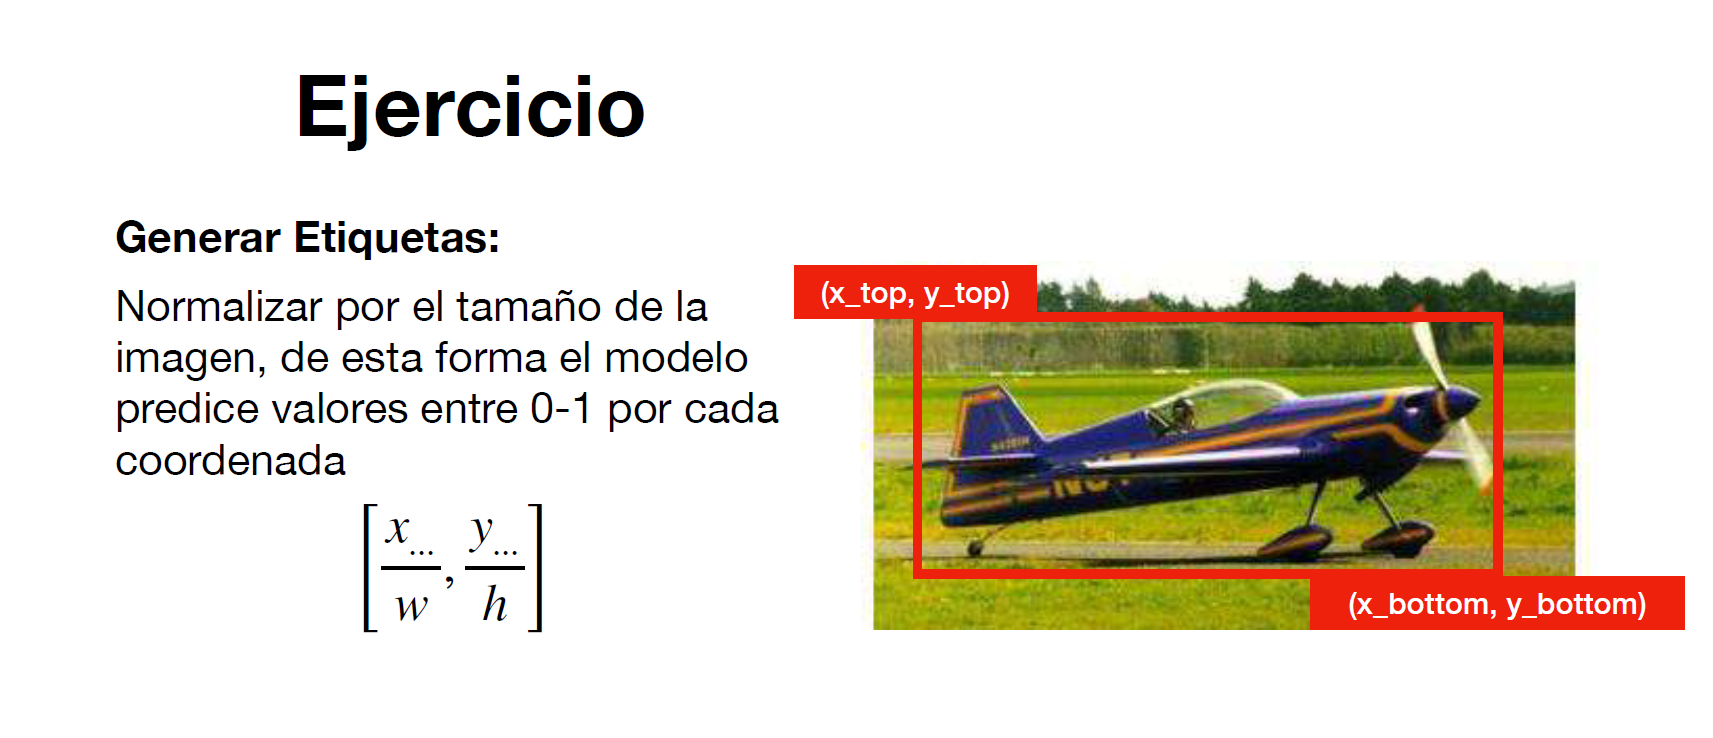

In [154]:
PATH_IMAGE = "/content/Data/airplanes"
H = 300
W = 300
df_train['y_top_norm'] = df_train['y_top_n']/H
df_train['y_bottom_norm'] = df_train['y_bottom_n']/H
df_train['x_top_norm'] = df_train['x_top_n']/W
df_train['x_bottom_norm'] = df_train['x_bottom_n']/W




In [155]:
df_train

,Unnamed: 0,Image,y_top,y_bottom,x_top,x_bottom,label,x_top_n,y_top_n,x_bottom_n,y_bottom_n,y_top_norm,y_bottom_norm,x_top_norm,x_bottom_norm
0,0,image_0001.jpg,30,137,49,349,Airplanes,36.0,54.0,263.0,250.0,0.180000,0.833333,0.120000,0.876667
1,0,image_0002.jpg,35,153,59,342,Airplanes,44.0,57.0,255.0,249.0,0.190000,0.830000,0.146667,0.850000
2,0,image_0003.jpg,36,135,47,331,Airplanes,35.0,65.0,252.0,245.0,0.216667,0.816667,0.116667,0.840000
3,0,image_0004.jpg,24,141,47,342,Airplanes,35.0,42.0,261.0,248.0,0.140000,0.826667,0.116667,0.870000
4,0,image_0005.jpg,18,146,48,339,Airplanes,36.0,30.0,257.0,248.0,0.100000,0.826667,0.120000,0.856667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0,image_0796.jpg,27,118,57,356,Airplanes,41.0,56.0,259.0,245.0,0.186667,0.816667,0.136667,0.863333
796,0,image_0797.jpg,25,110,56,350,Airplanes,41.0,55.0,259.0,242.0,0.183333,0.806667,0.136667,0.863333
797,0,image_0798.jpg,25,110,59,354,Airplanes,43.0,56.0,259.0,248.0,0.186667,0.826667,0.143333,0.863333
798,0,image_0799.jpg,26,116,49,347,Airplanes,36.0,55.0,261.0,246.0,0.183333,0.820000,0.120000,0.870000


In [156]:
df_train["Encoded_Label"] = df_train[["x_top_norm", "y_top_norm", "x_bottom_norm", "y_bottom_norm"]].values.tolist()

In [157]:
df_train["File"] = df_train["Image"].apply(lambda x: os.path.join(PATH_IMAGE, x))

In [158]:
df_train["Encoded_Label"] = df_train["Encoded_Label"].apply(
    lambda x: np.array(x, dtype=np.float32)
)

In [159]:
df_train

,Unnamed: 0,Image,y_top,y_bottom,x_top,x_bottom,label,x_top_n,y_top_n,x_bottom_n,y_bottom_n,y_top_norm,y_bottom_norm,x_top_norm,x_bottom_norm,Encoded_Label,File
0,0,image_0001.jpg,30,137,49,349,Airplanes,36.0,54.0,263.0,250.0,0.180000,0.833333,0.120000,0.876667,"[0.12, 0.18, 0.87666667, 0.8333333]",/content/Data/airplanes/image_0001.jpg
1,0,image_0002.jpg,35,153,59,342,Airplanes,44.0,57.0,255.0,249.0,0.190000,0.830000,0.146667,0.850000,"[0.14666666, 0.19, 0.85, 0.83]",/content/Data/airplanes/image_0002.jpg
2,0,image_0003.jpg,36,135,47,331,Airplanes,35.0,65.0,252.0,245.0,0.216667,0.816667,0.116667,0.840000,"[0.11666667, 0.21666667, 0.84, 0.81666666]",/content/Data/airplanes/image_0003.jpg
3,0,image_0004.jpg,24,141,47,342,Airplanes,35.0,42.0,261.0,248.0,0.140000,0.826667,0.116667,0.870000,"[0.11666667, 0.14, 0.87, 0.82666665]",/content/Data/airplanes/image_0004.jpg
4,0,image_0005.jpg,18,146,48,339,Airplanes,36.0,30.0,257.0,248.0,0.100000,0.826667,0.120000,0.856667,"[0.12, 0.1, 0.8566667, 0.82666665]",/content/Data/airplanes/image_0005.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0,image_0796.jpg,27,118,57,356,Airplanes,41.0,56.0,259.0,245.0,0.186667,0.816667,0.136667,0.863333,"[0.13666667, 0.18666667, 0.86333334, 0.81666666]",/content/Data/airplanes/image_0796.jpg
796,0,image_0797.jpg,25,110,56,350,Airplanes,41.0,55.0,259.0,242.0,0.183333,0.806667,0.136667,0.863333,"[0.13666667, 0.18333334, 0.86333334, 0.8066667]",/content/Data/airplanes/image_0797.jpg
797,0,image_0798.jpg,25,110,59,354,Airplanes,43.0,56.0,259.0,248.0,0.186667,0.826667,0.143333,0.863333,"[0.14333333, 0.18666667, 0.86333334, 0.82666665]",/content/Data/airplanes/image_0798.jpg
798,0,image_0799.jpg,26,116,49,347,Airplanes,36.0,55.0,261.0,246.0,0.183333,0.820000,0.120000,0.870000,"[0.12, 0.18333334, 0.87, 0.82]",/content/Data/airplanes/image_0799.jpg


## Praparation of the DataSet

From Keras, we used **flow_from_dataframe** to get the path of the images and their coordenates from a CSV file.

* The image are normalized 1/255
*   The dataset was split into 80% for trainning and 20 % for validation.




In [160]:
#Image normalization
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255)

In [161]:
from sklearn.model_selection import train_test_split

In [163]:
train_, test = train_test_split(df_train,test_size=0.1, random_state=42)

In [164]:
train, val = train_test_split(train_,test_size=0.30, random_state=42)

In [165]:
train['Encoded_Label'].iloc[0].dtype

dtype('float32')

In [166]:
len(train), len(test), len(val), len(train) + len(test) + len(val)

(504, 80, 216, 800)

In [167]:
# Convert your Encoded_Label column from object to numpy array float 32
train['Encoded_Label'] = train['Encoded_Label'].apply(lambda x: np.array(x, dtype=np.float32))
test['Encoded_Label'] = test['Encoded_Label'].apply(lambda x: np.array(x, dtype=np.float32))
val['Encoded_Label'] = val['Encoded_Label'].apply(lambda x: np.array(x, dtype=np.float32))

In [168]:
train

,Unnamed: 0,Image,y_top,y_bottom,x_top,x_bottom,label,x_top_n,y_top_n,x_bottom_n,y_bottom_n,y_top_norm,y_bottom_norm,x_top_norm,x_bottom_norm,Encoded_Label,File
376,0,image_0377.jpg,80,157,68,350,Airplanes,48.0,109.0,248.0,214.0,0.363333,0.713333,0.160000,0.826667,"[0.16, 0.36333334, 0.82666665, 0.7133333]",/content/Data/airplanes/image_0377.jpg
573,0,image_0574.jpg,28,124,49,346,Airplanes,37.0,54.0,261.0,243.0,0.180000,0.810000,0.123333,0.870000,"[0.123333335, 0.18, 0.87, 0.81]",/content/Data/airplanes/image_0574.jpg
491,0,image_0492.jpg,26,107,56,348,Airplanes,42.0,60.0,261.0,248.0,0.200000,0.826667,0.140000,0.870000,"[0.14, 0.2, 0.87, 0.82666665]",/content/Data/airplanes/image_0492.jpg
730,0,image_0731.jpg,27,105,50,346,Airplanes,37.0,61.0,262.0,238.0,0.203333,0.793333,0.123333,0.873333,"[0.123333335, 0.20333333, 0.87333333, 0.79333335]",/content/Data/airplanes/image_0731.jpg
208,0,image_0209.jpg,42,158,65,345,Airplanes,47.0,60.0,250.0,225.0,0.200000,0.750000,0.156667,0.833333,"[0.15666667, 0.2, 0.8333333, 0.75]",/content/Data/airplanes/image_0209.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,0,image_0003.jpg,36,135,47,331,Airplanes,35.0,65.0,252.0,245.0,0.216667,0.816667,0.116667,0.840000,"[0.11666667, 0.21666667, 0.84, 0.81666666]",/content/Data/airplanes/image_0003.jpg
576,0,image_0577.jpg,25,118,55,353,Airplanes,40.0,52.0,261.0,249.0,0.173333,0.830000,0.133333,0.870000,"[0.13333334, 0.17333333, 0.87, 0.83]",/content/Data/airplanes/image_0577.jpg
531,0,image_0532.jpg,25,122,52,347,Airplanes,39.0,52.0,260.0,255.0,0.173333,0.850000,0.130000,0.866667,"[0.13, 0.17333333, 0.8666667, 0.85]",/content/Data/airplanes/image_0532.jpg
757,0,image_0758.jpg,23,119,48,345,Airplanes,36.0,48.0,264.0,249.0,0.160000,0.830000,0.120000,0.880000,"[0.12, 0.16, 0.88, 0.83]",/content/Data/airplanes/image_0758.jpg


In [169]:
test

,Unnamed: 0,Image,y_top,y_bottom,x_top,x_bottom,label,x_top_n,y_top_n,x_bottom_n,y_bottom_n,y_top_norm,y_bottom_norm,x_top_norm,x_bottom_norm,Encoded_Label,File
696,0,image_0697.jpg,31,116,56,352,Airplanes,42.0,63.0,264.0,238.0,0.210000,0.793333,0.140000,0.880000,"[0.14, 0.21, 0.88, 0.79333335]",/content/Data/airplanes/image_0697.jpg
667,0,image_0668.jpg,30,121,53,347,Airplanes,39.0,60.0,261.0,243.0,0.200000,0.810000,0.130000,0.870000,"[0.13, 0.2, 0.87, 0.81]",/content/Data/airplanes/image_0668.jpg
63,0,image_0064.jpg,37,140,46,342,Airplanes,35.0,66.0,261.0,250.0,0.220000,0.833333,0.116667,0.870000,"[0.11666667, 0.22, 0.87, 0.8333333]",/content/Data/airplanes/image_0064.jpg
533,0,image_0534.jpg,23,100,47,346,Airplanes,35.0,57.0,264.0,247.0,0.190000,0.823333,0.116667,0.880000,"[0.11666667, 0.19, 0.88, 0.8233333]",/content/Data/airplanes/image_0534.jpg
66,0,image_0067.jpg,25,150,44,343,Airplanes,33.0,41.0,261.0,250.0,0.136667,0.833333,0.110000,0.870000,"[0.11, 0.13666667, 0.87, 0.8333333]",/content/Data/airplanes/image_0067.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,0,image_0200.jpg,31,135,56,346,Airplanes,41.0,57.0,258.0,250.0,0.190000,0.833333,0.136667,0.860000,"[0.13666667, 0.19, 0.86, 0.8333333]",/content/Data/airplanes/image_0200.jpg
365,0,image_0366.jpg,32,146,54,352,Airplanes,39.0,53.0,258.0,246.0,0.176667,0.820000,0.130000,0.860000,"[0.13, 0.17666666, 0.86, 0.82]",/content/Data/airplanes/image_0366.jpg
486,0,image_0487.jpg,27,117,53,347,Airplanes,40.0,56.0,263.0,245.0,0.186667,0.816667,0.133333,0.876667,"[0.13333334, 0.18666667, 0.87666667, 0.81666666]",/content/Data/airplanes/image_0487.jpg
594,0,image_0595.jpg,29,131,57,350,Airplanes,42.0,54.0,262.0,244.0,0.180000,0.813333,0.140000,0.873333,"[0.14, 0.18, 0.87333333, 0.81333333]",/content/Data/airplanes/image_0595.jpg


In [170]:
val

,Unnamed: 0,Image,y_top,y_bottom,x_top,x_bottom,label,x_top_n,y_top_n,x_bottom_n,y_bottom_n,y_top_norm,y_bottom_norm,x_top_norm,x_bottom_norm,Encoded_Label,File
507,0,image_0508.jpg,28,133,54,349,Airplanes,40.0,53.0,263.0,252.0,0.176667,0.840000,0.133333,0.876667,"[0.13333334, 0.17666666, 0.87666667, 0.84]",/content/Data/airplanes/image_0508.jpg
125,0,image_0126.jpg,35,117,56,346,Airplanes,41.0,68.0,258.0,229.0,0.226667,0.763333,0.136667,0.860000,"[0.13666667, 0.22666667, 0.86, 0.7633333]",/content/Data/airplanes/image_0126.jpg
302,0,image_0303.jpg,33,137,50,342,Airplanes,38.0,59.0,260.0,247.0,0.196667,0.823333,0.126667,0.866667,"[0.12666667, 0.19666667, 0.8666667, 0.8233333]",/content/Data/airplanes/image_0303.jpg
223,0,image_0224.jpg,33,125,52,346,Airplanes,39.0,63.0,261.0,238.0,0.210000,0.793333,0.130000,0.870000,"[0.13, 0.21, 0.87, 0.79333335]",/content/Data/airplanes/image_0224.jpg
684,0,image_0685.jpg,27,121,54,350,Airplanes,40.0,54.0,261.0,243.0,0.180000,0.810000,0.133333,0.870000,"[0.13333334, 0.18, 0.87, 0.81]",/content/Data/airplanes/image_0685.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,0,image_0276.jpg,27,105,40,345,Airplanes,30.0,62.0,258.0,242.0,0.206667,0.806667,0.100000,0.860000,"[0.1, 0.20666666, 0.86, 0.8066667]",/content/Data/airplanes/image_0276.jpg
440,0,image_0441.jpg,31,101,54,355,Airplanes,40.0,72.0,262.0,234.0,0.240000,0.780000,0.133333,0.873333,"[0.13333334, 0.24, 0.87333333, 0.78]",/content/Data/airplanes/image_0441.jpg
410,0,image_0411.jpg,27,91,57,355,Airplanes,41.0,68.0,258.0,229.0,0.226667,0.763333,0.136667,0.860000,"[0.13666667, 0.22666667, 0.86, 0.7633333]",/content/Data/airplanes/image_0411.jpg
252,0,image_0253.jpg,31,126,44,343,Airplanes,33.0,59.0,261.0,242.0,0.196667,0.806667,0.110000,0.870000,"[0.11, 0.19666667, 0.87, 0.8066667]",/content/Data/airplanes/image_0253.jpg


In [171]:
train_generator = datagen.flow_from_dataframe(
    dataframe=train,
    x_col='File',
    y_col='Encoded_Label',
    target_size=(300, 300),  # Resize images
    batch_size=32,
    subset='training',  # Use for training subset
    class_mode = "raw",
    shuffle=True
)

Found 504 validated image filenames.


In [173]:
val_generator = datagen.flow_from_dataframe(
    dataframe=val,
    x_col='File',
    y_col='Encoded_Label',
    target_size=(300, 300),  # Resize images
    batch_size=32,
    subset='training',  # Use for training subset
    class_mode = "raw",
    shuffle=True
)

Found 216 validated image filenames.


In [174]:
test_generator = datagen.flow_from_dataframe(
    dataframe=test,
    x_col='File',
    y_col='Encoded_Label',
    target_size=(300, 300),  # Resize images
    batch_size=32,
    subset='training',  # Use for training subset
    class_mode = "raw",
    shuffle=True
)

Found 80 validated image filenames.


In [175]:
images, labels = next(train_generator)
print(labels.shape)

(32,)


In [176]:
def bbox_generator(original_gen):
    for batch_x, batch_y in original_gen:
        # batch_y is a list of 32 arrays → stack them into (32, 4)
        batch_y = np.stack(batch_y).astype("float32")
        yield batch_x, batch_y

In [177]:
train_gen_fixed = bbox_generator(train_generator)
val_gen_fixed = bbox_generator(val_generator)
test_gen_fixed = bbox_generator(test_generator)

In [178]:
images, labels = next(val_gen_fixed)
print(labels.shape)

(32, 4)


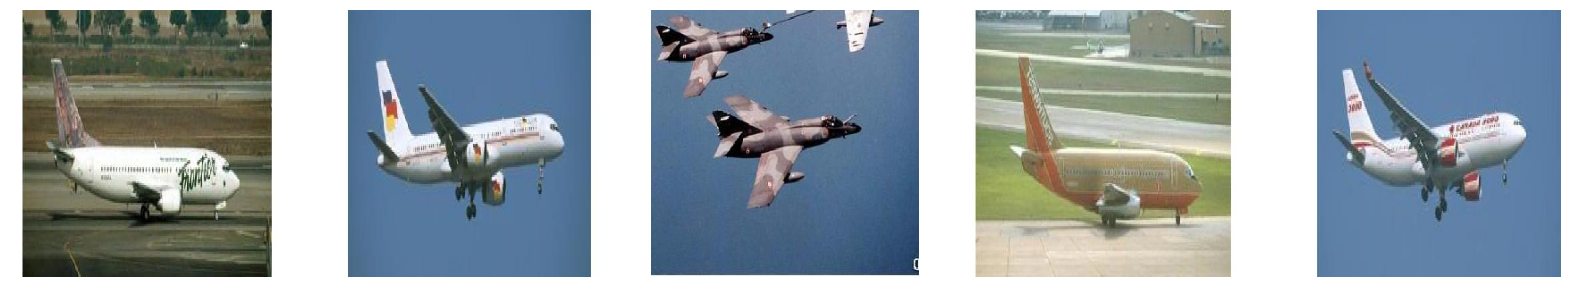

In [179]:
# Fetch a batch of images from the test generator
images = next(train_gen_fixed)


# Plotting the first few images in the batch
num_images_to_show = 5  # Number of images to display

plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow(images[0][i])
    plt.axis("off")


plt.show()

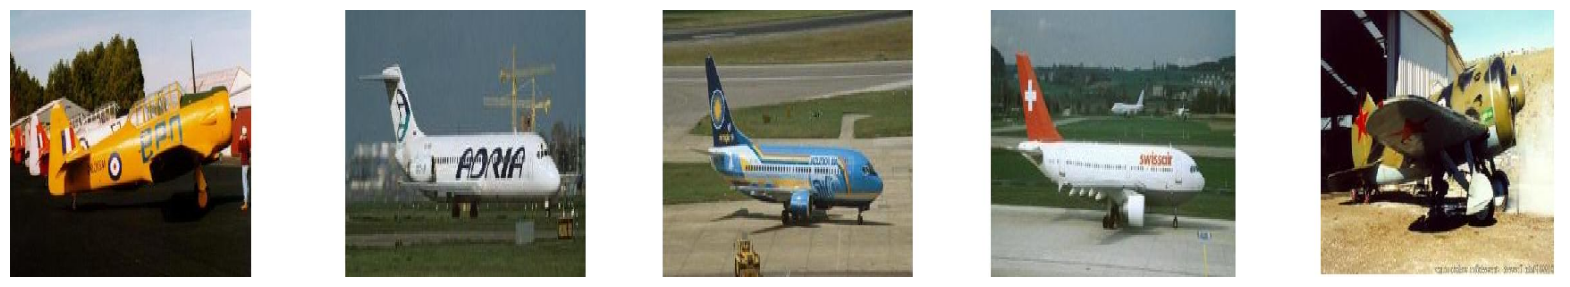

In [180]:
images = next(val_gen_fixed)


# Plotting the first few images in the batch
num_images_to_show = 5  # Number of images to display

plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow(images[0][i])
    plt.axis("off")

    # If predictions are available, display them
    #plt.title(f"Label: {int(images[1][i])}")

plt.show()

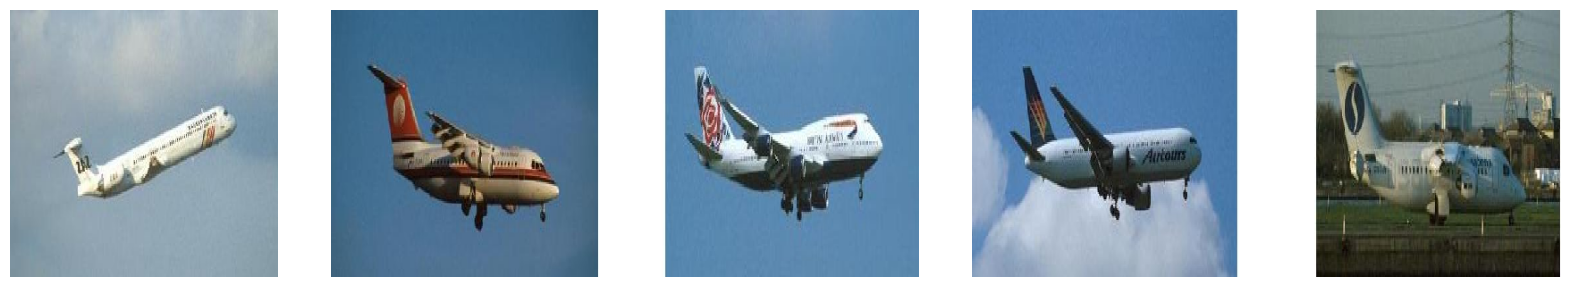

In [181]:
images = next(test_gen_fixed)


# Plotting the first few images in the batch
num_images_to_show = 5  # Number of images to display

plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow(images[0][i])
    plt.axis("off")

    # If predictions are available, display them
    #plt.title(f"Label: {int(images[1][i])}")

plt.show()

In [182]:
print(train["Encoded_Label"].iloc[0])
print(type(train["Encoded_Label"].iloc[0]))

[0.16       0.36333334 0.82666665 0.7133333 ]
<class 'numpy.ndarray'>


In [183]:
train["Encoded_Label"]

,Encoded_Label
376,"[0.16, 0.36333334, 0.82666665, 0.7133333]"
573,"[0.123333335, 0.18, 0.87, 0.81]"
491,"[0.14, 0.2, 0.87, 0.82666665]"
730,"[0.123333335, 0.20333333, 0.87333333, 0.79333335]"
208,"[0.15666667, 0.2, 0.8333333, 0.75]"
...,...
2,"[0.11666667, 0.21666667, 0.84, 0.81666666]"
576,"[0.13333334, 0.17333333, 0.87, 0.83]"
531,"[0.13, 0.17333333, 0.8666667, 0.85]"
757,"[0.12, 0.16, 0.88, 0.83]"


In [184]:
from keras.optimizers import Adam

In [185]:
bb_regressor.compile(
    optimizer = optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)

In [186]:
images, labels = next(train_generator)
print(images.shape)   # Expected: (32, 224, 224, 3)
print(labels.shape)   # Expected: (32, 4)
print(labels[:3])

(32, 300, 300, 3)
(32,)
[array([0.14666666, 0.32333332, 0.83      , 0.74      ], dtype=float32)
 array([0.14333333, 0.19333333, 0.86333334, 0.82      ], dtype=float32)
 array([0.14333333, 0.17666666, 0.85333335, 0.83      ], dtype=float32)]


In [187]:

EPOCHS = 20
history = bb_regressor.fit(
    train_gen_fixed,
    validation_data=val_gen_fixed,
    epochs=EPOCHS,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 109s 4s/step - loss: 0.0424 - mae: 0.1450 - val_loss: 0.0114 - val_mae: 0.0715
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 623ms/step - loss: 0.0078 - mae: 0.0596 - val_loss: 0.0104 - val_mae: 0.0651
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 766ms/step - loss: 0.0023 - mae: 0.0337 - val_loss: 0.0105 - val_mae: 0.0647
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 649ms/step - loss: 0.0017 - mae: 0.0250 - val_loss: 0.0090 - val_mae: 0.0575
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 635ms/step - loss: 0.0013 - mae: 0.0219 - val_loss: 0.0068 - val_mae: 0.0517
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 640ms/step - loss: 0.0010 - mae: 0.0169 - val_loss: 0.0041 - val_mae: 0.0400
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 642ms/step - loss: 4.3509e-04 - mae: 0.0140 - val_loss: 8.4798e-04 - val_mae: 0.0182
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 648ms/step - loss: 4.1934e-04 - mae: 0.0124 - val_loss: 9.8941e-04 - val_mae: 0.0204
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━

In [188]:
bb_regressor.save("bb1_regressor.keras")

In [189]:
images_batch, labels_batch = next(test_gen_fixed)

In [190]:
preds = bb_regressor.predict(images_batch)

print("Predicted normalized bounding box:", preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted normalized bounding box: [[0.13685909 0.19640651 0.8632833  0.8104824 ]
 [0.136848   0.19639221 0.8633107  0.81049585]
 [0.13685909 0.19640651 0.8632833  0.8104824 ]
 [0.13683176 0.19636984 0.8633461  0.810513  ]
 [0.13685906 0.19640647 0.86328334 0.8104825 ]
 [0.13685909 0.19640651 0.8632833  0.8104824 ]
 [0.13685909 0.19640651 0.8632833  0.8104824 ]
 [0.13685909 0.19640651 0.8632833  0.8104824 ]
 [0.13685909 0.19640651 0.8632833  0.8104824 ]
 [0.13685909 0.19640651 0.8632833  0.8104824 ]
 [0.13685909 0.19640651 0.8632833  0.8104824 ]
 [0.13643463 0.1961471  0.8643541  0.8108541 ]
 [0.13685909 0.19640651 0.8632833  0.8104824 ]
 [0.13901545 0.22628276 0.86672515 0.7824198 ]
 [0.13685507 0.19640109 0.8632926  0.81048703]
 [0.13685909 0.1964065  0.8632833  0.8104824 ]
 [0.13685909 0.19640651 0.8632833  0.8104824 ]
 [0.13685898 0.19640636 0.8632835  0.81048256]
 [0.13685907 0.19640648 0.86328334 0.8104825 ]
 [0.13685909 0.19640651 0.8632833  0

In [191]:
print("Final training loss:", history.history['loss'][-1])
print("Final validation loss:", history.history['val_loss'][-1])

Final training loss: 8.944794535636902e-05
Final validation loss: 0.0007516644545830786


# Visualization of Predictions vs Ground Truth

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
300 300
300 300
300 300
300 300
300 300


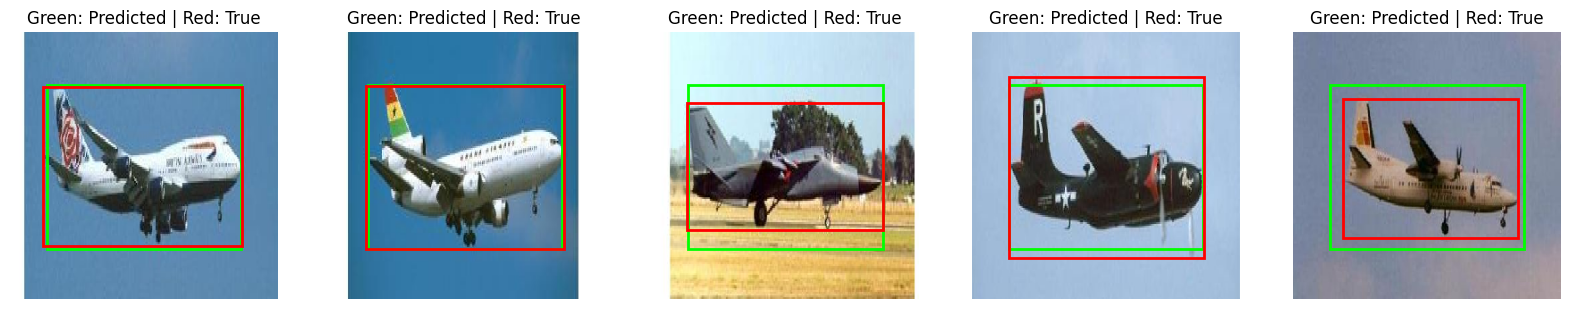

In [195]:


import matplotlib.patches as patches


# Get one batch of image validation data
images, true_bboxes = next(test_gen_fixed)

# Predict bounding boxes for this batch
pred_bboxes = bb_regressor.predict(images)

# Show first few predictions
num_images_to_show = 5
plt.figure(figsize=(20, 10))

for i in range(num_images_to_show):
    img = images[i]
    pred = pred_bboxes[i]
    true = true_bboxes[i]

    # Image size
    h, w = img.shape[:2]
    print(h, w)

    # Denormalize (convert 0–1 coords to pixel values)
    px_min, py_min, px_max, py_max = pred[0]*w, pred[1]*h, pred[2]*w, pred[3]*h
    tx_min, ty_min, tx_max, ty_max = true[0]*w, true[1]*h, true[2]*w, true[3]*h

    # Plot image
    ax = plt.subplot(1, num_images_to_show, i + 1)
    ax.imshow(img)
    ax.axis("off")

    # Predicted box (green)
    rect_pred = patches.Rectangle(
        (px_min, py_min),
        px_max - px_min,
        py_max - py_min,
        linewidth=2,
        edgecolor='lime',
        facecolor='none',
        label="Predicted"
    )
    ax.add_patch(rect_pred)

    #True box (red)
    rect_true = patches.Rectangle(
        (tx_min, ty_min),
        tx_max - tx_min,
        ty_max - ty_min,
        linewidth=2,
        edgecolor='red',
        facecolor='none',
        label="True"
    )
    ax.add_patch(rect_true)

    ax.set_title(f"Green: Predicted | Red: True")

plt.show()